In [94]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titaniccompetition/train.csv
/kaggle/input/titaniccompetition/test.csv
/kaggle/input/titaniccompetition/gender_submission.csv


In [95]:
train=pd.read_csv('/kaggle/input/titaniccompetition/train.csv')
test=pd.read_csv('/kaggle/input/titaniccompetition/test.csv')
train.head()
#test.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


EDA

<Axes: xlabel='Sex', ylabel='Survived'>

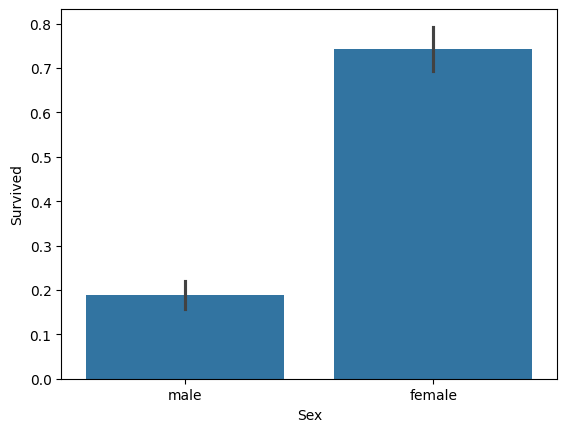

In [96]:
import seaborn as sns 
import matplotlib.pyplot as plt
sns.barplot(data=train_df,y='Survived',x='Sex')

<Axes: xlabel='Pclass', ylabel='Sex'>

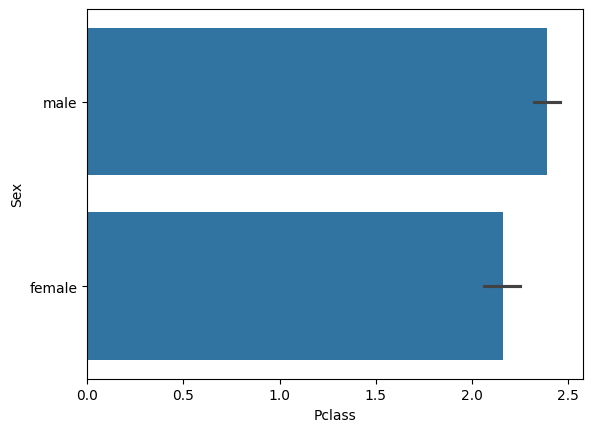

In [97]:
sns.barplot(data=train_df,y='Sex',x='Pclass')

<Axes: xlabel='Age', ylabel='Count'>

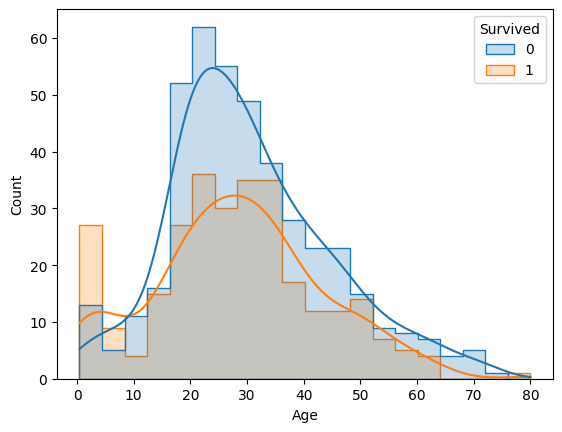

In [98]:
sns.histplot(data=train_df, x='Age', hue='Survived', kde=True, element='step')

<Axes: >

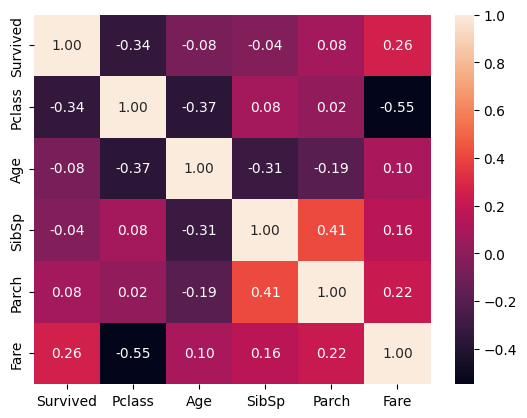

In [99]:
num=train_df.select_dtypes(include=['number'])
sns.heatmap(num.corr(),annot=True,fmt='.2f')

Preprocess Data definition 

In [100]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import accuracy_score

num_cols=list(num.columns)
num_cols.remove('Survived')
cat_cols=list(train_df.select_dtypes(include=['object']))
cat_cols.remove('Name')
cat_cols.remove('Ticket')
cat_cols.remove('Cabin')
y=train_df['Survived']
X=train_df[num_cols+cat_cols]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

#Pipeline Creation 
num_transf=Pipeline(steps=[('imputer',SimpleImputer(strategy='mean')),
                                           ('Scaler',StandardScaler())
                                          ])

cat_transf=Pipeline(steps=[('Imputer',SimpleImputer(strategy='most_frequent')),
                                           ('OneHotEncoder',OneHotEncoder(handle_unknown='ignore',sparse_output=False))
                                          ])

preprocess=ColumnTransformer(transformers=[('num',num_transf,num_cols),
                                           ('cat',cat_transf,cat_cols)
                                          ])

final_pipeline=Pipeline(steps=[('preprocess',preprocess),
                               ('model',RandomForestClassifier(n_estimators=100,max_depth=5,random_state=42))])

#cross validation

cv_score=cross_val_score(final_pipeline,X_train,y_train,cv=5)
print('Cross Validation Score:',cv_score.mean())

final_pipeline.fit(X_train,y_train)

y_pred=final_pipeline.predict(X_val)

acc_score=accuracy_score(y_pred,y_val)

print('Accuracy Score:',acc_score)




                             

Cross Validation Score: 0.8201812272234807
Accuracy Score: 0.8100558659217877


We can see that the model is stable and robust, so next step is train the model with the totally of the train data to make test predictions 

In [101]:
#Fit with all data 
final_pipeline.fit(X,y)

#Predictions 
final_pred=final_pipeline.predict(test)

In [102]:

submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": final_pred
})


submission.to_csv('submission_titanic.csv', index=False)

